In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

main_colours = plt.cm.rainbow(np.linspace(0, 1, 10))

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "#131313",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),
}

sns.set_theme(context="talk", style="ticks", rc=custom_params)

/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_47207/544012266.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


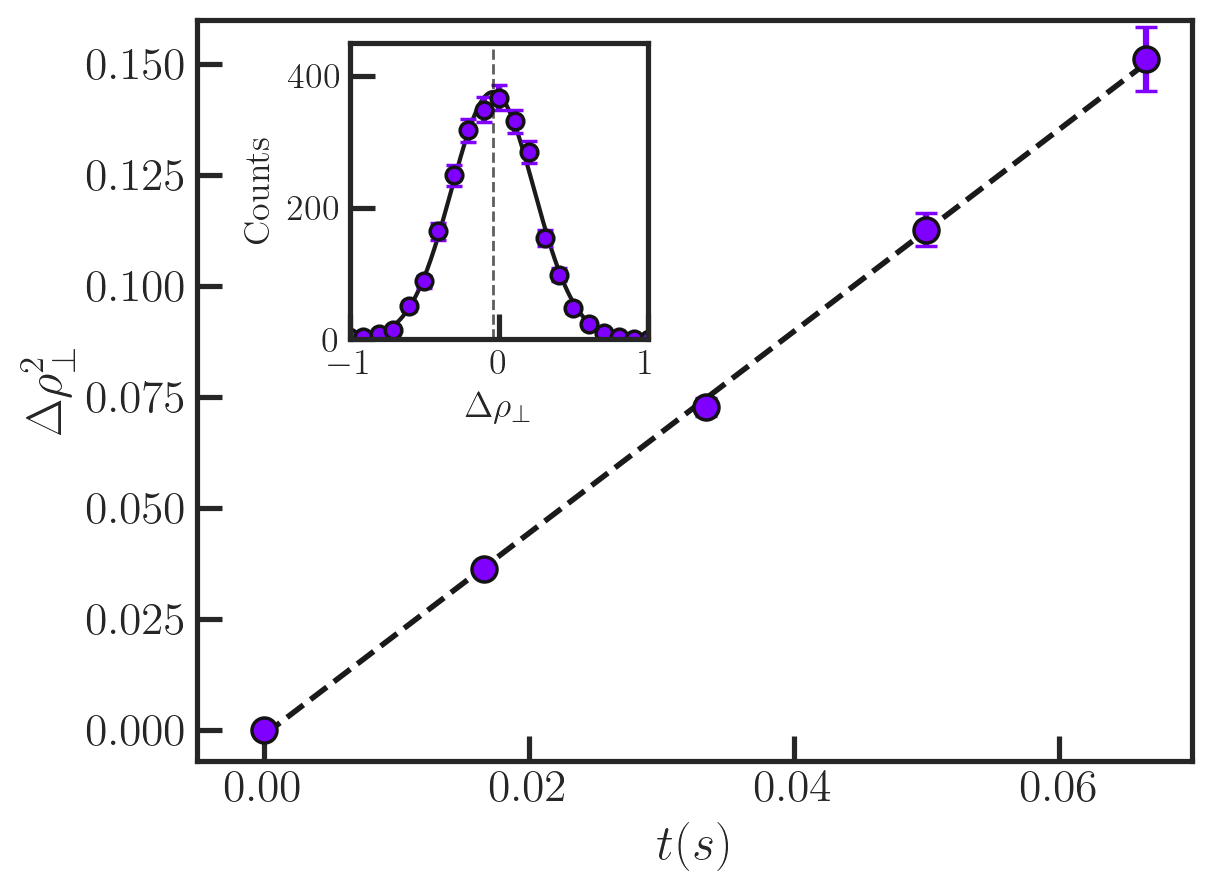

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------
# MAIN DATA
# -----------------------
df_main = pd.read_csv("points_msd_dufresne.csv", sep=";")

x_main = df_main["Tau"].to_numpy()
y_main = df_main["Avg"].to_numpy()

coeffs = np.polyfit(x_main, y_main, 1)
slope, intercept = coeffs

x_fit_main = np.linspace(x_main.min(), x_main.max(), 500)
y_fit_main = slope * x_fit_main + intercept

lower_main = df_main["Avg"] - df_main["Lower Bound"]
upper_main = df_main["Higher Bound"] - df_main["Avg"]
yerr_main = [lower_main, upper_main]


# -----------------------
# INSET DATA
# -----------------------
df_inset = pd.read_csv("points_dufresne_histo_inlet.csv", sep=";")

x_inset = df_inset["del_rho"].to_numpy()
y_inset = df_inset["Avg"].to_numpy()

lower_inset = (df_inset["Avg"] - df_inset["Lowerbound"]).to_numpy()
upper_inset = (df_inset["Higherbound"] - df_inset["Avg"]).to_numpy()
yerr_inset = [lower_inset, upper_inset]


def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


A0 = y_inset.max()
mu0 = x_inset[np.argmax(y_inset)]
sigma0 = np.std(x_inset)

popt, _ = curve_fit(gaussian, x_inset, y_inset, p0=[A0, mu0, sigma0])

x_fit = np.linspace(x_inset.min(), x_inset.max(), 500)
y_fit = gaussian(x_fit, *popt)


# -----------------------
# PLOTTING
# -----------------------
fig, ax = plt.subplots()

# Main plot
ax.errorbar(x_main, y_main, yerr=yerr_main, fmt="o", capsize=4, linestyle="none")

ax.plot(x_fit_main, y_fit_main, color="k", linestyle="--", label="_None_", linewidth=2)
ax.set_xlim(-0.005, 0.07)
ax.set_ylim(-0.007, 0.160)
# ax.legend()
ax.set_xlabel(r"$t (s)$")
ax.set_ylabel(r"$\Delta \rho_\perp^2$")


# -----------------------
# INSET
# -----------------------
ax_inset = inset_axes(
    ax,
    width="30%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.13, 0, 1, 1),
    bbox_transform=ax.transAxes,
)
ax_inset.errorbar(
    x_inset,
    y_inset,
    yerr=yerr_inset,
    fmt="o",
    capsize=3,
    markersize=6,
    linestyle="none",
)

ax_inset.plot(x_fit, y_fit, color="k", zorder=-1, linewidth=1.5)
ax_inset.vlines(popt[1], 0, 450, color="k", linestyle="--", alpha=0.7, linewidth=1)

ax_inset.set_xlabel(r"$\Delta \rho_\perp ~~~$", fontsize=13)
ax_inset.set_ylabel("Counts", fontsize=13)
ax_inset.set_xlim(-1, 1)
ax_inset.set_ylim(0, 450)

ax_inset.tick_params(axis="both", which="major", labelsize=13)

plt.tight_layout()
plt.savefig("dufresne_results.pdf", transparent=True)

#close far shites

In [4]:
A_UM = 0.495
ETA_PA_S = 0.813e-3
KB_T_J = 4.171631e-21


def theory_D_um(h_um: float, r_um: float, a_um: float = A_UM):
    a_m = a_um * 1e-6
    h_m = h_um * 1e-6
    r_m = r_um * 1e-6

    D0_m2_s = KB_T_J / (6 * np.pi * a_m * ETA_PA_S)

    xi = 4 * (h_m**2) / (r_m**2)

    DparC_m2_s = (
        2
        * D0_m2_s
        * (
            1
            - 9 / 16 * a_m / h_m
            + 3 / 2 * a_m / r_m * (1 - (1 + xi + 3 / 2 * xi**2) / (1 + xi) ** (5 / 2))
        )
    )
    DperpC_m2_s = (
        2
        * D0_m2_s
        * (
            1
            - 9 / 16 * a_m / h_m
            + 3 / 4 * a_m / r_m * (1 - (1 + 3 / 2 * xi) / (1 + xi) ** (3 / 2))
        )
    )

    DparR_m2_s = (
        2
        * D0_m2_s
        * (
            1
            - 9 / 16 * a_m / h_m
            - 3 / 2 * a_m / r_m * (1 - (1 + xi + 3 / 2 * xi**2) / (1 + xi) ** (5 / 2))
        )
    )
    DperpR_m2_s = (
        2
        * D0_m2_s
        * (
            1
            - 9 / 16 * a_m / h_m
            - 3 / 4 * a_m / r_m * (1 - (1 + 3 / 2 * xi) / (1 + xi) ** (3 / 2))
        )
    )

    ######
    Dxy_m2_s = D0_m2_s * (1 - 9 / 16 * a_m / h_m)

    DparC_m2_s_naive = (
        (2 * D0_m2_s) ** (-1) * (1 + 3 / 2 * a_m / r_m) ** (-1)
        + (Dxy_m2_s ** (-1) - D0_m2_s ** (-1)) / 2
    ) ** (-1)
    DperpC_m2_s_naive = (
        (2 * D0_m2_s) ** (-1) * (1 + 3 / 4 * a_m / r_m) ** (-1)
        + (Dxy_m2_s ** (-1) - D0_m2_s ** (-1)) / 2
    ) ** (-1)

    DparR_m2_s_naive = (
        (2 * D0_m2_s) ** (-1) * (1 - 3 / 2 * a_m / r_m) ** (-1)
        + (Dxy_m2_s ** (-1) - D0_m2_s ** (-1)) / 2
    ) ** (-1)
    DperpR_m2_s_naive = (
        (2 * D0_m2_s) ** (-1) * (1 - 3 / 4 * a_m / r_m) ** (-1)
        + (Dxy_m2_s ** (-1) - D0_m2_s ** (-1)) / 2
    ) ** (-1)

    conv = 1e12

    return (
        DparC_m2_s * conv,
        DperpC_m2_s * conv,
        DparR_m2_s * conv,
        DperpR_m2_s * conv,
        D0_m2_s * conv,
        Dxy_m2_s * conv,
        DparC_m2_s_naive * conv,
        DperpC_m2_s_naive * conv,
        DparR_m2_s_naive * conv,
        DperpR_m2_s_naive * conv,
    )

DCPAR_close
DRPAR_close
DCPERP_close
DRPERP_CLOSE
DCPAR_Far
DRPAR_far
DCPERP_far
DRPERP_FAR


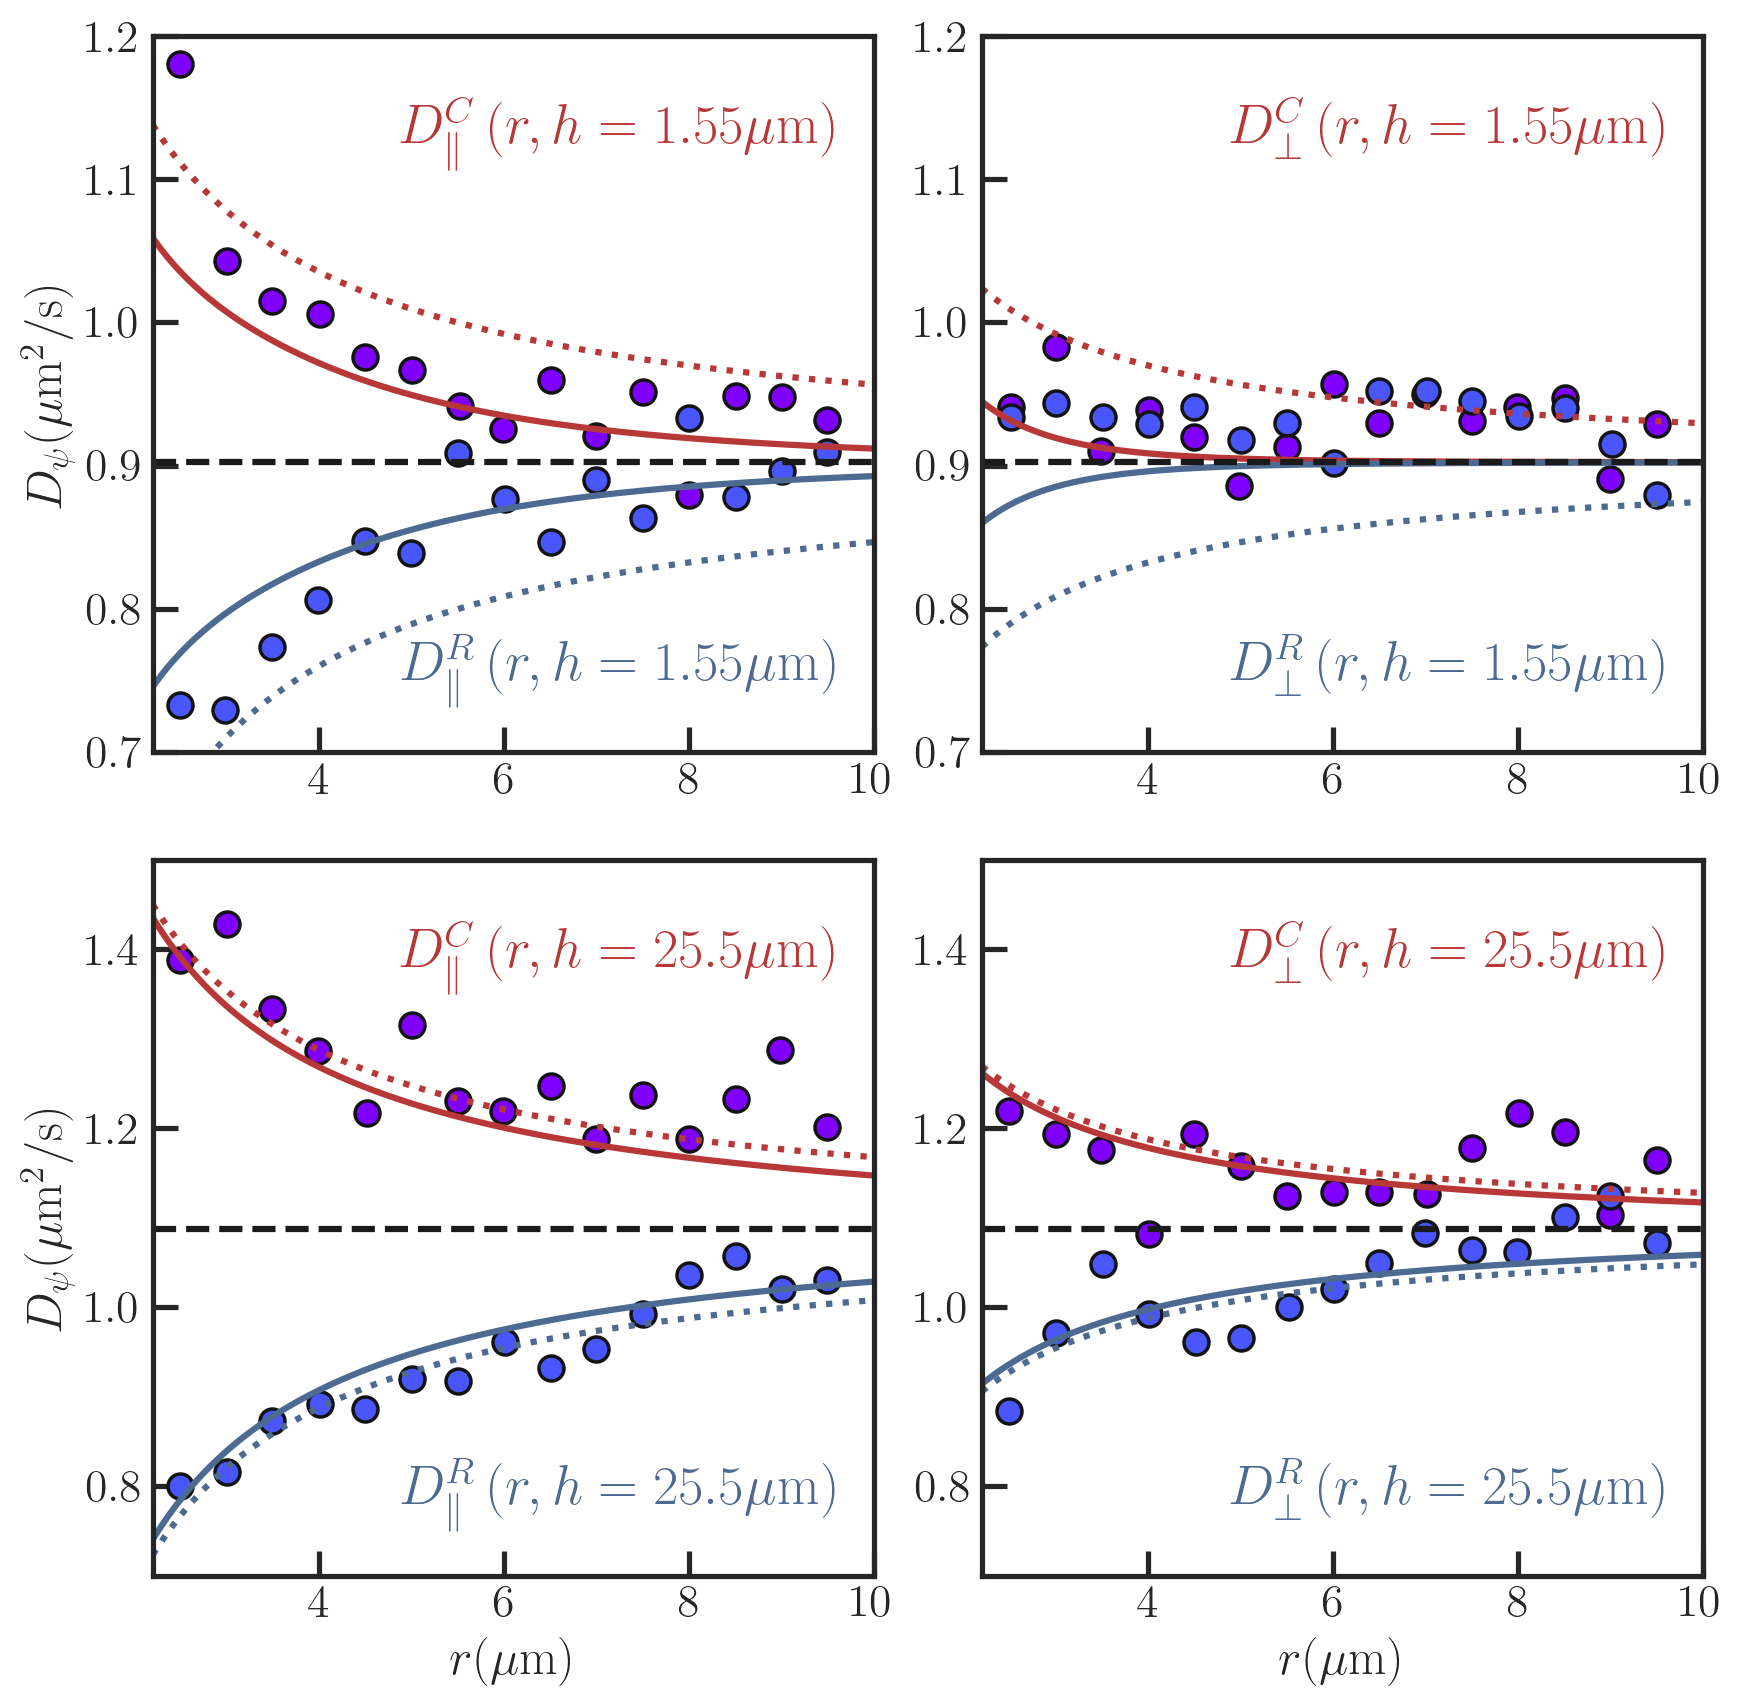

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def fix_columns(df):
    new_cols = []
    last = None

    for col in df.columns:
        if "Unnamed" not in col[0]:
            last = col[0]
            new_cols.append((last, col[1]))
        else:
            new_cols.append((last, col[1]))

    df.columns = pd.MultiIndex.from_tuples(new_cols)
    return df


# -----------------------
# MAIN DATA
# -----------------------
df_par_close = pd.read_csv("par_close.csv", sep=",", header=[0, 1])
df_perp_close = pd.read_csv("perp_close.csv", sep=",", header=[0, 1])
df_par_far = pd.read_csv("par_far.csv", sep=",", header=[0, 1])
df_perp_far = pd.read_csv("perp_far.csv", sep=",", header=[0, 1])

df_par_close = fix_columns(df_par_close)
df_perp_close = fix_columns(df_perp_close)
df_par_far = fix_columns(df_par_far)
df_perp_far = fix_columns(df_perp_far)

# print(df_perp_close.columns)
# print(list(df_perp_close.columns))

# print(df_par_close)

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=False, sharey=False)
axes = axes.ravel()

dfs = [
    ("par_close", df_par_close),
    ("perp_close", df_perp_close),
    ("par_far", df_par_far),
    ("perp_far", df_perp_far),
]


d_space = np.linspace(2.2, 10, 1000)
for ax, (title, df) in zip(axes, dfs):
    # first-level names present in the dataframe
    groups = df.columns.get_level_values(0).unique()

    for g in groups:
        print(g)
        if ("X" in df[g].columns) and ("Y" in df[g].columns):
            ax.plot(df[g]["X"], df[g]["Y"], marker="o", linestyle="None", label=g)

    if ax == axes[0]:
        h = 1.55
        (
            DparC,
            DperpC,
            DparR,
            DperpR,
            D0,
            Dxy,
            DparC_m2_s_naive,
            DperpC_m2_s_naive,
            DparR_m2_s_naive,
            DperpR_m2_s_naive,
        ) = theory_D_um(h, d_space)
        ax.plot(d_space, DparC, label="DparC", linestyle="-", color="#b83737")
        ax.plot(d_space, DparR, label="DparR", linestyle="-", color="#4C6A92")
        ax.hlines(
            2 * Dxy, d_space.min(), d_space.max(), label="D0", linestyle="--", color="k"
        )
        ax.plot(
            d_space,
            DparC_m2_s_naive,
            label="DparC naive",
            linestyle=":",
            color="#b83737",
        )
        ax.plot(
            d_space,
            DparR_m2_s_naive,
            label="DparR naive",
            linestyle=":",
            color="#4C6A92",
        )
        # ax.set_title(title)
        ax.set_ylabel(r"$D_\psi (\mu \mathrm{m}^2/\mathrm{s})$")
        ax.text(
            0.65,
            0.85,
            r"$D^C_\parallel \, (r, h = 1.55 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#b83737",
        )
        ax.text(
            0.65,
            0.1,
            r"$D^R_\parallel \, (r, h = 1.55 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#4C6A92",
        )

    elif ax == axes[1]:
        h = 1.55
        (
            DparC,
            DperpC,
            DparR,
            DperpR,
            D0,
            Dxy,
            DparC_m2_s_naive,
            DperpC_m2_s_naive,
            DparR_m2_s_naive,
            DperpR_m2_s_naive,
        ) = theory_D_um(h, d_space)
        ax.plot(d_space, DperpC, label="DperpC", linestyle="-", color="#b83737")
        ax.plot(d_space, DperpR, label="DperpR", linestyle="-", color="#4C6A92")
        ax.hlines(
            2 * Dxy, d_space.min(), d_space.max(), label="D0", linestyle="--", color="k"
        )
        ax.plot(
            d_space,
            DperpC_m2_s_naive,
            label="DperpC naive",
            linestyle=":",
            color="#b83737",
        )
        ax.plot(
            d_space,
            DperpR_m2_s_naive,
            label="DperpR naive",
            linestyle=":",
            color="#4C6A92",
        )
        ax.text(
            0.65,
            0.85,
            r"$D^C_\perp \, (r, h = 1.55 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#b83737",
        )
        ax.text(
            0.65,
            0.1,
            r"$D^R_\perp \, (r, h = 1.55 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#4C6A92",
        )

    elif ax == axes[2]:
        h = 25.5
        (
            DparC,
            DperpC,
            DparR,
            DperpR,
            D0,
            Dxy,
            DparC_m2_s_naive,
            DperpC_m2_s_naive,
            DparR_m2_s_naive,
            DperpR_m2_s_naive,
        ) = theory_D_um(h, d_space)
        ax.plot(d_space, DparC, label="DparC", linestyle="-", color="#b83737")
        ax.plot(d_space, DparR, label="DparR", linestyle="-", color="#4C6A92")
        ax.hlines(
            2 * Dxy, d_space.min(), d_space.max(), label="D0", linestyle="--", color="k"
        )
        ax.plot(
            d_space,
            DparC_m2_s_naive,
            label="DparC naive",
            linestyle=":",
            color="#b83737",
        )
        ax.plot(
            d_space,
            DparR_m2_s_naive,
            label="DparR naive",
            linestyle=":",
            color="#4C6A92",
        )
        ax.set_ylabel(r"$D_\psi (\mu \mathrm{m}^2/\mathrm{s})$")
        ax.set_xlabel(r"$r (\mu \mathrm{m})$")
        ax.text(
            0.65,
            0.85,
            r"$D^C_\parallel \, (r, h = 25.5 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#b83737",
        )
        ax.text(
            0.65,
            0.1,
            r"$D^R_\parallel \, (r, h = 25.5 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#4C6A92",
        )

    elif ax == axes[3]:
        h = 25.5
        (
            DparC,
            DperpC,
            DparR,
            DperpR,
            D0,
            Dxy,
            DparC_m2_s_naive,
            DperpC_m2_s_naive,
            DparR_m2_s_naive,
            DperpR_m2_s_naive,
        ) = theory_D_um(h, d_space)
        ax.plot(d_space, DperpC, label="DperpC", linestyle="-", color="#b83737")
        ax.plot(d_space, DperpR, label="DperpR", linestyle="-", color="#4C6A92")
        ax.hlines(
            2 * Dxy, d_space.min(), d_space.max(), label="D0", linestyle="--", color="k"
        )
        ax.plot(
            d_space,
            DperpC_m2_s_naive,
            label="DperpC naive",
            linestyle=":",
            color="#b83737",
        )
        ax.plot(
            d_space,
            DperpR_m2_s_naive,
            label="DperpR naive",
            linestyle=":",
            color="#4C6A92",
        )
        ax.set_xlabel(r"$r (\mu \mathrm{m})$")
        ax.text(
            0.65,
            0.85,
            r"$D^C_\perp \, (r, h = 25.5 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#b83737",
        )
        ax.text(
            0.65,
            0.1,
            r"$D^R_\perp \, (r, h = 25.5 \mu \mathrm{m})$",
            transform=ax.transAxes,
            ha="center",
            fontsize=20,
            color="#4C6A92",
        )

    # ax.grid(True)


axes[0].set_xlim(2.2, 10)
axes[0].set_ylim(0.7, 1.2)

axes[1].set_xlim(2.2, 10)
axes[1].set_ylim(0.7, 1.2)

axes[2].set_xlim(2.2, 10)
axes[2].set_ylim(0.7, 1.5)

axes[3].set_xlim(2.2, 10)
axes[3].set_ylim(0.7, 1.5)

plt.subplots_adjust(wspace=0.15, hspace=0.15)
# plt.tight_layout()
plt.savefig("dufresne_final_result.pdf", transparent=True)
plt.show()

# Plotting the effective diffusion coefficients for the one colloids case

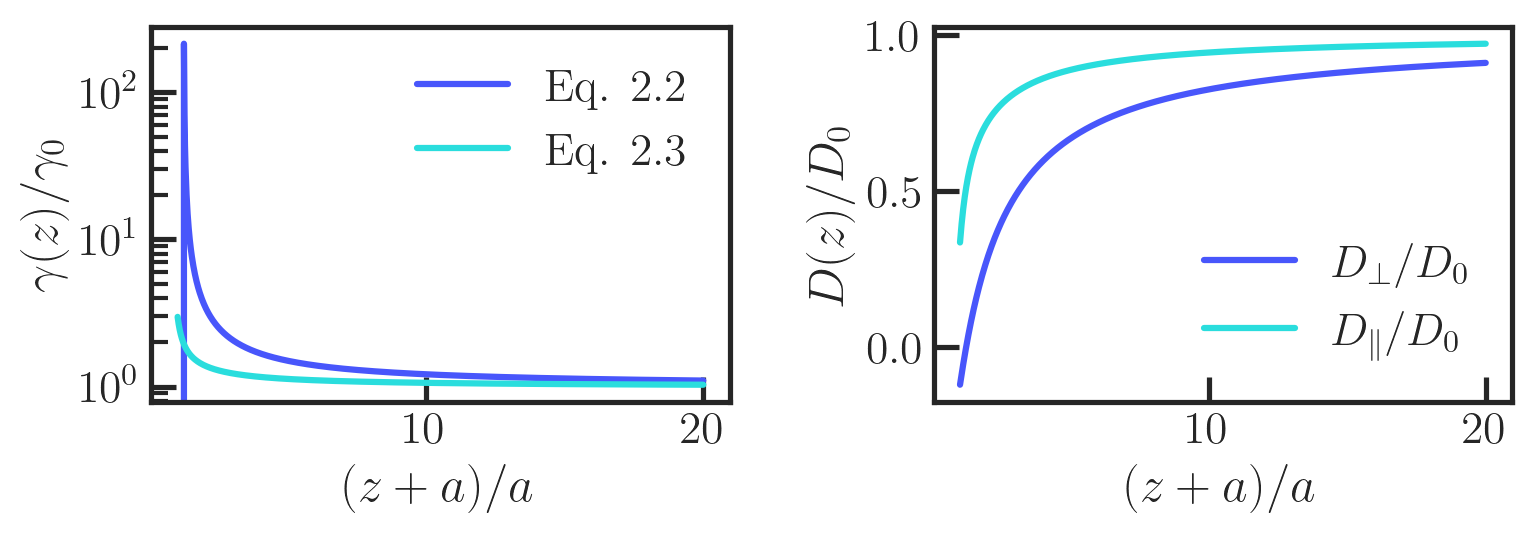

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical parameters
# ============================================================

kB = 1.380649e-23
T = 298
eta = 1e-3
a = 0.5e-6


z = np.linspace(1.01 * a, 20 * a, 1000)


eta_perp = eta * (6 * z**2 + 2 * a * z) / (6 * z**2 - 9 * a * z + 2 * a**2)

eta_para = eta / (
    1
    - (9 / 16) * (a / z)
    + (1 / 8) * (a / z) ** 3
    - (45 / 256) * (a / z) ** 4
    - (1 / 16) * (a / z) ** 5
)


D0 = kB * T / (6 * np.pi * eta * a)

D_perp = kB * T / (6 * np.pi * a * eta_perp)
D_para = kB * T / (6 * np.pi * a * eta_para)


fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharex=True)


ax[0].plot(z / a, eta_perp / eta, label=r"Eq. 2.2", color="C1")

ax[0].plot(z / a, eta_para / eta, label=r"Eq. 2.3", color="C3")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$(z+a)/a$")
ax[0].set_ylabel(r"$\gamma(z)/\gamma_0$")
ax[0].legend(frameon=False)
# ax[0].grid(alpha=0.3)


ax[1].plot(z / a, D_perp / D0, label=r"$D_\perp/D_0$", color="C1")

ax[1].plot(z / a, D_para / D0, label=r"$D_\parallel/D_0$", color="C3")

ax[1].set_xlabel(r"$(z+a)/a$")
ax[1].set_ylabel(r"$D(z)/D_0$")
ax[1].legend(frameon=False)
# ax[1].grid()

plt.tight_layout()
plt.savefig("diffusion_coefficients_brenpad.pdf", transparent=True)

plt.show()